In [24]:
pip install tensorflow matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten,
    Dropout, BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [6]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 3

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [8]:
train_data = train_datagen.flow_from_directory(
    'data/train',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_test_datagen.flow_from_directory(
    'data/train',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = val_test_datagen.flow_from_directory(
    'data/train',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 14682 images belonging to 12 classes.
Found 14682 images belonging to 12 classes.
Found 14682 images belonging to 12 classes.


In [9]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(train_data.num_classes, activation='softmax')
])

In [10]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 222, 222, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 batch_normalization_1 (Bat  (None, 109, 109, 64)      256       
 chNormalization)                                                
                                                        

In [13]:
history = model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data
)

Epoch 1/3
459/459 [==============================] - 12030s 26s/step - loss: 0.8368 - accuracy: 0.7639 - val_loss: 1.2097 - val_accuracy: 0.6592
Epoch 2/3
459/459 [==============================] - 1058s 2s/step - loss: 0.3849 - accuracy: 0.8737 - val_loss: 0.2395 - val_accuracy: 0.9140
Epoch 3/3
459/459 [==============================] - 1041s 2s/step - loss: 0.2832 - accuracy: 0.9078 - val_loss: 0.1451 - val_accuracy: 0.9463


In [14]:
test_loss, test_accuracy = model.evaluate(test_data)
print("Test Accuracy:", test_accuracy)

459/459 [==============================] - 223s 486ms/step - loss: 0.1451 - accuracy: 0.9463
Test Accuracy: 0.9463288187980652


In [15]:
model.save("fruit_vegetable_freshness_model.h5")

c:\Users\KASHIF\AppData\Local\Programs\Python\Python38\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


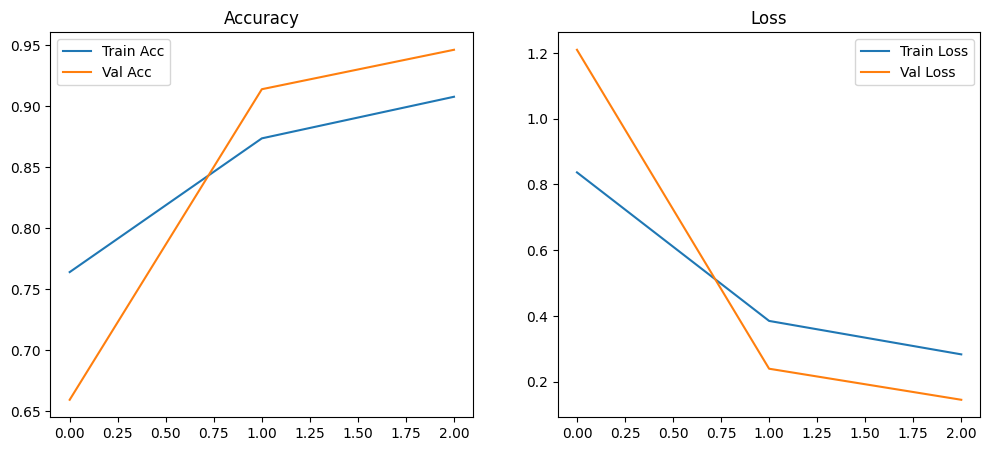

In [16]:
print(history.history.keys())
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [19]:
import numpy as np
from tensorflow.keras.preprocessing import image

# ===== INPUT SECTION =====
paths_input = input(
    "Enter image paths (comma separated):\n"
)

image_paths = [p.strip() for p in paths_input.split(",")]

# ===== PROCESSING =====
images = []
valid_paths = []

for path in image_paths:
    try:
        img = image.load_img(path, target_size=(224, 224))
        img = image.img_to_array(img) / 255.0
        images.append(img)
        valid_paths.append(path)
    except Exception as e:
        print(f"❌ Skipped: {path} ({e})")

# Convert to batch
images = np.array(images)

# ===== PREDICTION =====
predictions = model.predict(images)
class_labels = list(train_data.class_indices.keys())

print("\n🔍 Prediction Results:\n")
for i, pred in enumerate(predictions):
    idx = np.argmax(pred)
    confidence = pred[idx] * 100
    print(f"{valid_paths[i]} → {class_labels[idx]} ({confidence:.2f}%)")

1/1 [==============================] - 0s 72ms/step

🔍 Prediction Results:

C:\Users\KASHIF\Desktop\FYP\data\train\stale_apple\rotated_by_15_Screen Shot 2018-06-07 at 2.15.20 PM.png → stale_apple (97.82%)
